In [180]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
from scipy.integrate import odeint
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [181]:
m = 0.1
r = 0.1
d = 0.3
g = 9.81

In [182]:
# Definir las ecuaciones de movimiento del trompo
def trompo(y,t,theta0,w0,d):

    # Unpacking
    phi, psi, theta, dtheta = y

    I0 = 1/4*m*r**2 + m*d**2
    Iz = 1/2*m*r**2

    dydt = np.zeros_like(y)

    Pphi = Iz*w0*np.cos(theta0)
    Ppsi = Iz*w0

    Ip = (I0*np.sin(theta)**2+Iz*np.cos(theta)**2)*Iz - Iz**2*np.cos(theta)**2

    dydt[0] = (Iz*Pphi - Iz*np.cos(theta)*Ppsi)/Ip
    dydt[1] = ((I0*np.sin(theta)**2+Iz*np.cos(theta)**2)*Ppsi - Iz*np.cos(theta)*Pphi)/Ip

    dydt[2] = dtheta

    dydt[3] = dydt[0]**2*np.sin(theta)*np.cos(theta)*(I0 - Iz) - \
              dydt[0]*dydt[1]*Iz*np.sin(theta) + \
              m*g*d*np.sin(theta)

    dydt[3] = dydt[3]/I0

    return dydt

In [183]:
# Condiciones iniciales
phi0 = 0.
psi0 = 0.
theta0 = np.deg2rad(30)
dtheta0 = 0.
y0 = [phi0, psi0, theta0, dtheta0]

In [184]:
# Tiempo de integración
t = np.linspace(0., 6., 100)
# Resolver las ecuaciones de movimiento
sol = odeint(trompo, y0, t, args=(theta0,300,d))

In [185]:
phi = sol[:,0]
psi = sol[:,1]
theta = sol[:,2]
dtheta = sol[:,3]

In [186]:
x1 = d*np.sin(theta)*np.cos(phi)
y1 = d*np.sin(theta)*np.sin(phi)
z1 = d*np.cos(theta)

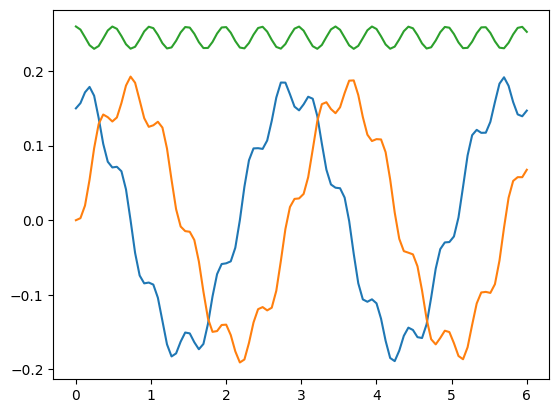

In [187]:
plt.plot(t,x1)
plt.plot(t,y1)
plt.plot(t,z1)

In [188]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(121,projection = '3d',elev = 30, azim = 50)
ax1 = fig.add_subplot(122)

def init():
  #ax1.clear()
  ax.set_xlim(-d, d)
  ax.set_ylim(-d, d)
  ax.set_zlim(-d, d)

def Update(i):

  init()
  x = d*np.sin(theta[i])*np.cos(phi[i])
  y = d*np.sin(theta[i])*np.sin(phi[i])
  z = d*np.cos(theta[i])

  ax.scatter(x,y,z,marker='.',color='k',s=50)
  ax.plot([0.,x],[0.,y],[0.,z],color='r')

  ax1.plot(t[:i],theta[:i],color='r')
  return []


# Crear animación
ani = FuncAnimation(fig, Update, frames=len(t), init_func=init, interval=1)
plt.close()
# Mostrar en Colab
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.